In [ ]:
import numpy as np                                 # Numerical computations
import matplotlib.pyplot as plt                    # Plotting
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import multivariate_normal        # Statistics
from scipy.optimize import minimize                # Optimization
from sklearn.linear_model import LinearRegression  # Machine learning

# Training dataset

In [ ]:
######################
# 1-Dimensional data #
######################

x_data = [-12, -10, -5, -2.5, 2, 4, 6, 7.5]  # define training data
Xtrain = np.array(x_data).reshape(-1, 1)     # reshape data

# Functions to learn

Below are the functions that we will be learning with our machine learning algorithms.

In [ ]:
###########################
# 1-Dimensional functions #
###########################

def sin_square(x):
    return np.sin(x) + (x/5)**2

def gauss3(x):
    # Define parameters of Gaussians
    gaus_params = np.array([[1., 2., -8.], [1.5, 1.5, 0.], [1.4, 1., 5.]])
    a, std, m = gaus_params.T
    # Initialize the evaluation array
    eval = np.zeros(x.shape)
    # Compute Gaussians
    for ai, stdi, mi in zip(a, std, m):
        eval += ai / (stdi * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((x - mi) / stdi) ** 2)
    return -eval


In [ ]:
# computing true output data Y
Ytrain_ss = sin_square(Xtrain)
Ytrain_3g = gauss3(Xtrain)

# computing true function values for visualization
x_points = np.linspace(-15, 15.0, num=100).reshape(-1, 1)
Ytrue_ss = sin_square(x_points)
Ytrue_3g = gauss3(x_points)


# Utilities

In [ ]:
####################
# evaluate ML model
###################

def evalML(x_points, modelss, model3g, n_d=100, GP_model=False):
    x_points = np.linspace(-15, 15.0, num=n_d).reshape(-1, 1)
    Yplot_ss, Yplot_3g = [], []

    if GP_model:
        Yplot_ss_var, Yplot_3g_var = [], []

    for xp_ in x_points:
        if GP_model:
            mss, sss = modelss.predict(xp_.reshape(-1, 1), return_std=True)
            m3g, s3g = model3g.predict(xp_.reshape(-1, 1), return_std=True)

            Yplot_ss.append(mss[0])
            Yplot_3g.append(m3g[0])
            Yplot_ss_var.append(sss[0])
            Yplot_3g_var.append(s3g[0])
        else:
            yp_ss = modelss.predict(xp_.reshape(-1, 1))
            yp_3g = model3g.predict(xp_.reshape(-1, 1))

            Yplot_ss.append(yp_ss[0])
            Yplot_3g.append(yp_3g[0])

    if GP_model:
        return np.array(Yplot_ss), np.array(Yplot_3g), \
        np.array(Yplot_ss_var), np.array(Yplot_3g_var)
    else:
        return np.array(Yplot_ss), np.array(Yplot_3g), x_points

In [ ]:
####################
# plot performance #
####################

def plot_results(x_points, Yplot_ss, Yplot_3g, title=None,
                 Xtrain=Xtrain, Ytrue_ss=Ytrue_ss, Ytrue_3g=Ytrue_3g,
                 Yplot_ss_var=None, Yplot_3g_var=None, step_plot=False):
    """
    Plots the results on two subplots.

    Parameters:
        x_points (array-like): Points on the x-axis.
        Yplot_ss (array-like): Predictions from the first model.
        Yplot_3g (array-like): Predictions from the second model.
        Yplot_ss_var (array-like, optional): Variance of the first model's predictions.
        Yplot_3g_var (array-like, optional): Variance of the second model's predictions.
    """
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4), sharex=True)

    # Plot for the first model
    axes[0].plot(x_points, Ytrue_ss, 'k-', lw=2)
    if step_plot == False:
        axes[0].plot(x_points, Yplot_ss, label='Model SS', color='blue')
    else:
        axes[0].step(x_points, Yplot_ss, label='Model SS', color='blue')
    axes[0].plot(Xtrain,   Ytrain_ss, 'ro', lw=2)
    if Yplot_ss_var is not None:
        axes[0].fill_between(x_points.flatten(),
                             (Yplot_ss - 1.96 * Yplot_ss_var).flatten(),
                             (Yplot_ss + 1.96 * Yplot_ss_var).flatten(),
                             color='blue', alpha=0.2)
    axes[0].set_ylabel('$\sin(x)+(x/5)^2$')
    axes[0].legend()
    axes[0].grid(True)

    # Plot for the second model
    axes[1].plot(x_points, Ytrue_3g, 'k-', lw=2)
    if step_plot == False:
        axes[1].plot(x_points, Yplot_3g, label='Model 3G', color='red')
    else:
        axes[1].step(x_points, Yplot_3g, label='Model 3G', color='red')
    axes[1].plot(Xtrain,   Ytrain_3g, 'ro', lw=2)
    if Yplot_3g_var is not None:
        axes[1].fill_between(x_points.flatten(),
                             (Yplot_3g - 1.96 * Yplot_3g_var).flatten(),
                             (Yplot_3g + 1.96 * Yplot_3g_var).flatten(),
                             color='red', alpha=0.2)
    axes[1].set_ylabel('Sum of Gaussians')
    axes[1].legend()
    axes[1].grid(True)

    # Common x-axis label
    axes[1].set_xlabel('X-axis')

    if title:
        fig.suptitle(title)

    plt.tight_layout(rect=[0, 0, 1, 0.99])
    plt.show()



# Machine Learning Models

## Linear regression

In [ ]:
##########################
# Linear Regression #
##########################

from sklearn.linear_model import LinearRegression


In [ ]:
# Creating a model that learns the 3 Gaussians function
LR_model_3G   = LinearRegression()
LR_model_3G.fit(Xtrain, Ytrain_3g)

# Creating a model that learns the Sin + Square function
LR_model_SS   = LinearRegression()
LR_model_SS.fit(Xtrain, Ytrain_ss)

LinearRegression()

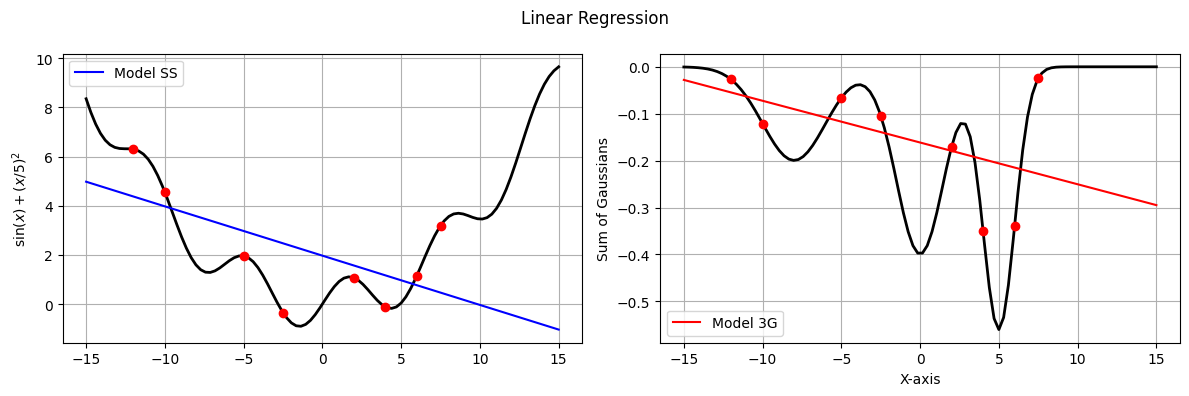

In [ ]:
Y_LR_ss, Y_LR_3g, x_points  = evalML(x_points, LR_model_SS, LR_model_3G)
plot_results(x_points, Y_LR_ss, Y_LR_3g, title='Linear Regression')

## Quadratic regression

In [ ]:
########################
# Quadratic Regression #
########################

class QuadraticRegressionModel:

    def __init__(self, X, Y):
        # GP variable definitions
        self.X, self.Y            = X, Y
        self.n_point, self.nx_dim = X.shape[0], X.shape[1]

        # Create the quadratic feature matrix
        Xquad = np.hstack((X, X**2))
        if self.nx_dim > 1:
            for dim_i in range(X.shape[1] - 1):
                for dim_j in range(dim_i + 1, X.shape[1]):
                    cross_term = (X[:, dim_i] * X[:, dim_j]).reshape(X.shape[0], 1)
                    Xquad      = np.hstack((Xquad, cross_term))

        # Add bias term
        Xquad = np.hstack((np.ones((Xquad.shape[0], 1)), Xquad))

        # Train model (find parameters)

        regularization_term = np.eye(Xquad.shape[1]) * 1e-6
        self.beta_quad      = np.linalg.inv(Xquad.T @ Xquad + regularization_term) @ Xquad.T @ Y

    def predict(self, xnew):
        '''
        Predicts y based on xnew
        '''
        # Reshape new data point
        xnew = xnew.reshape(1, -1)

        # Create the quadratic feature vector
        xquad = np.hstack((xnew, xnew**2))
        if xnew.shape[1] > 1:
            for dim_i in range(self.X.shape[1] - 1):
                for dim_j in range(dim_i + 1, self.X.shape[1]):
                    cross_term = (xnew[:, dim_i] * xnew[:, dim_j]).reshape(1, 1)
                    xquad      = np.hstack((xquad, cross_term))

        # Add bias term
        xquad = np.hstack((np.ones((1, 1)), xquad))

        return (xquad @ self.beta_quad)[0]


In [ ]:
# Use quadratic terms to fit the model for a 3 Gaussians function
QR_model_3G = QuadraticRegressionModel(Xtrain, Ytrain_3g)
Y_QR_3g     = [QR_model_3G.predict(xn) for xn in x_points]

# Use quadratic terms to fit the model for a Sin + Square function
QR_model_SS = QuadraticRegressionModel(Xtrain, Ytrain_ss)
Y_QR_ss     = [QR_model_SS.predict(xn) for xn in x_points]



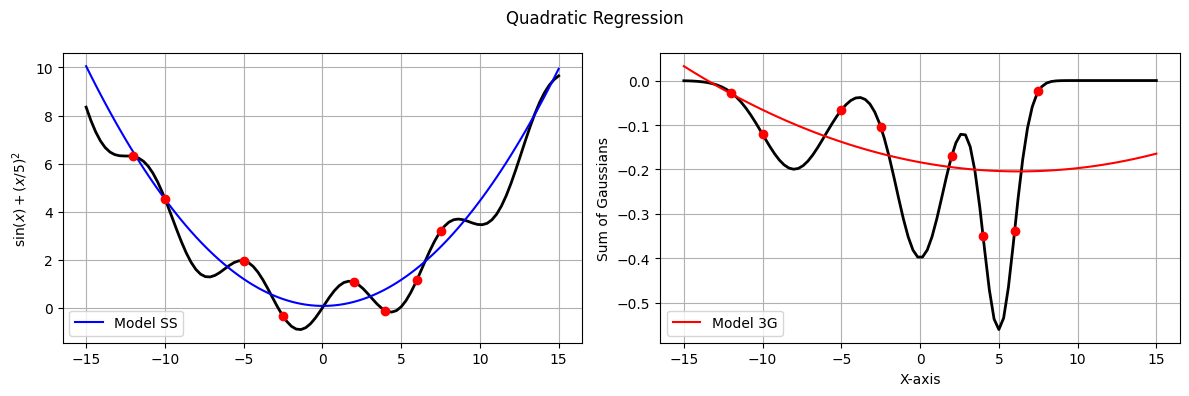

In [ ]:
Y_QR_ss, Y_QR_3g, x_points  = evalML(x_points, QR_model_SS, QR_model_3G)
plot_results(x_points, Y_QR_ss, Y_QR_3g, title='Quadratic Regression')

## Basis functions

In [ ]:
#############################
# Basis function Regression #
#############################

class BasisF_Regression_model:

    def __init__(self, X, Y):

        # BF variable definitions
        self.X, self.Y            = X, Y
        self.n_point, self.nx_dim = X.shape[0], X.shape[1]
        m_X                       = np.mean(np.abs(X), axis=0)[0]
        self.m_X                  = m_X

        # add quadratic model
        XBF = np.hstack((X, X*X ))
        for dim_i in range(X.shape[1]-1):
            for dim_j in range(dim_i+1, X.shape[1]):
                XBF = np.hstack((XBF, X[:,dim_i].reshape(X.shape[0],1)*X[:,dim_j].reshape(X.shape[0],1)))
        # add cubic model
        for dim_i in range(X.shape[1]):
            for dim_j in range(dim_i, X.shape[1]):
                for dim_k in range(dim_j, X.shape[1]):
                    XBF = np.hstack((XBF, (X[:,dim_i].reshape(X.shape[0],1)*
                                           X[:,dim_j].reshape(X.shape[0],1)*
                                           X[:,dim_k].reshape(X.shape[0],1)
                                          )))
        # add sin term
        XBF = np.hstack(( XBF, np.sin(X) ))
        XBF = np.hstack(( XBF, np.cos(X) ))
        # add bias term
        XBF = np.hstack(( np.ones((XBF.shape[0],1)), XBF ))

        # Training model (finding parameter)
        self.beta_BF = np.linalg.inv(XBF.T@XBF + np.eye(XBF.shape[1])*1e-6)@XBF.T@Y

    ######################
    # --- Prediction --- #
    ######################

    def predict(self, xnew):
        '''
        predicts y based on xnew
        '''
        # importing from class
        m_X = self.m_X
        X   = self.X

        # reshaping
        xnew = xnew.reshape(1,X.shape[1])
        # quadratic model
        xBF = np.hstack(( xnew, xnew*xnew ))
        for dim_i in range(X.shape[1]-1):
            for dim_j in range(dim_i+1, X.shape[1]):
                xBF = np.hstack((xBF, (xnew[:,dim_i]*xnew[:,dim_j].reshape(1,1))))
        # add cubic model
        for dim_i in range(X.shape[1]):
            for dim_j in range(dim_i, X.shape[1]):
                for dim_k in range(dim_j, X.shape[1]):
                    xBF = np.hstack((xBF, (xnew[:,dim_i]*xnew[:,dim_j]*xnew[:,dim_k]
                                     .reshape(1,1))))
        # add sin term
        xBF = np.hstack(( xBF, np.sin(xnew) ))
        xBF = np.hstack(( xBF, np.cos(xnew) ))
        # adding bias
        xBF = np.hstack((np.ones((1,1)), xBF))

        return (xBF@self.beta_BF)[0]

In [ ]:
############################
# Training basis functions #
############################

# Use quadratic terms to fit the model for a 3 Gaussians function
BF_model_3G = BasisF_Regression_model(Xtrain, Ytrain_3g)
Y_BF_3g     = [BF_model_3G.predict(xn) for xn in x_points]

# Use quadratic terms to fit the model for a Sin + Square function
BF_model_SS = BasisF_Regression_model(Xtrain, Ytrain_ss)
Y_BF_ss     = [BF_model_SS.predict(xn) for xn in x_points]



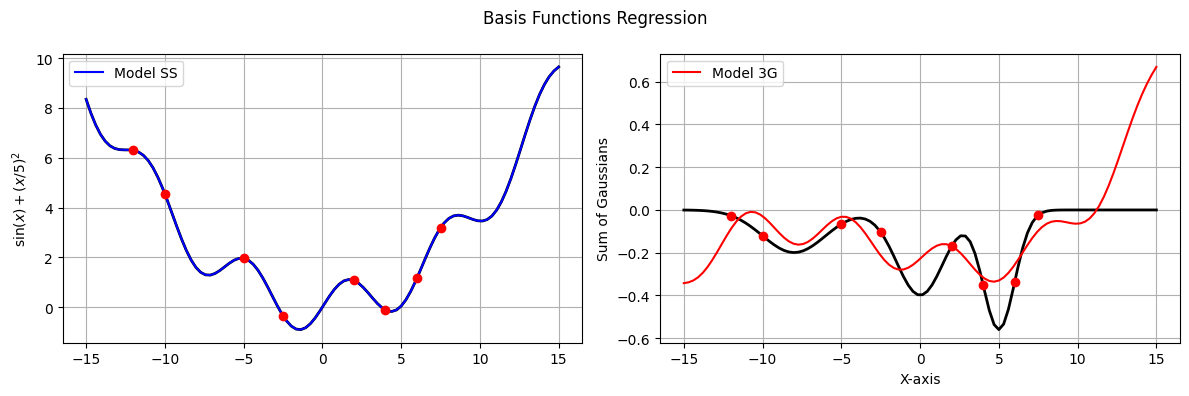

In [ ]:
Y_BF_ss, Y_BF_3g, x_points  = evalML(x_points, BF_model_SS, BF_model_3G)
plot_results(x_points, Y_BF_ss, Y_BF_3g, title='Basis Functions Regression')

## Radial basis functions

In [ ]:
##########################
# Radial Basis Functions #
##########################

class RBF_model:

    def __init__(self, X, Y, s=1):

        # internalize inputs
        self.X = X
        self.s = s
        # extracting dimensions
        n_p      = X.shape[0] # number of points
        try:
            self.n_y = Y.shape[1]
        except:
            print("Assumed only 1 output")
            self.n_y = 1
            Y        = Y.reshape(n_p,self.n_y)
        self.Y     = Y
        self.Ymean = np.mean(Y, axis=0)

        # starting matrix
        W_mat = np.zeros((n_p, n_p))

        # Constructing matrix W_mat
        # Note: this loop can be made faster (e.g. with np.vectorize)
        for p_i in range(n_p):
            for p_j in range(n_p):
                W_mat[p_i,p_j] = self.RBF(X[p_i,:], X[p_j,:], s)
                if p_i==p_j:
                    W_mat[p_i,p_j] += 1e-6

        self.W_mat = W_mat

        # Estimating parameters
        n_par = (X.shape[0]+1)*self.n_y
        p0    = np.ones(n_par)
        res   = minimize(self.LS_RBF, x0=p0, method='SLSQP')
        # obtaining solution
        params      = res.x
        self.params = params

    #################################
    # --- Radial Basis Function --- #
    #################################

    def RBF(self, x, x_j, s):
        return np.sum(np.exp(-(s)*(x - x_j)**2))

    #################################
    # --- Least Squares for RBF --- #
    #################################

    def LS_RBF(self, params):
        '''
        W_mat: matrix of radial distances: (n_d,n_d)
        Y:     vecor:  [f(x^(1)),...,f(x^(n_d))]
        '''
        # number of datapoints & dimensions
        n_y   = self.n_y                 # outputs
        n_p   = self.X.shape[0]          # points
        n_par = (self.X.shape[0]+1)*n_y  # dimensions
        Y     = self.Y
        Y     = Y.reshape((n_p,n_y))

        # weighted least squares
        LS = 0
        for ii in range(n_y):
            LS += np.sum((self.W_mat@params[(n_p+1)*ii:(n_p+1)*ii+n_p] +
                          self.Ymean[ii]
                        - self.Y[:,ii])**2)/n_p + 1e-6*np.sum(params**2)/n_p
        return LS

    ######################
    # --- Prediction --- #
    ######################

    def predict(self, xnew):
        '''
        redicts y based on xnew
        '''
        # extracting dimensions
        n_x  = self.X.shape[1]
        n_p  = self.X.shape[0] # number of points
        ynew = np.zeros((self.n_y))

        # compute new entry
        for i_y in range(self.n_y):
            wnew      = np.array([self.RBF(xnew, self.X[p_i,:], self.s) for p_i in range(n_p)])
            ynew[i_y] = np.sum(self.params[(n_p+1)*i_y:(n_p+1)*i_y+n_p]*wnew) + self.Ymean[i_y]

        return ynew


In [ ]:
############################
# Training basis functions #
############################

# Use quadratic terms to fit the model for a 3 Gaussians function
RBF_model_3G = RBF_model(Xtrain, Ytrain_3g)
Y_RBF_3g     = [RBF_model_3G.predict(xn) for xn in x_points]

# Use quadratic terms to fit the model for a Sin + Square function
RBF_model_SS = RBF_model(Xtrain, Ytrain_ss)
Y_RBF_ss     = [RBF_model_SS.predict(xn) for xn in x_points]



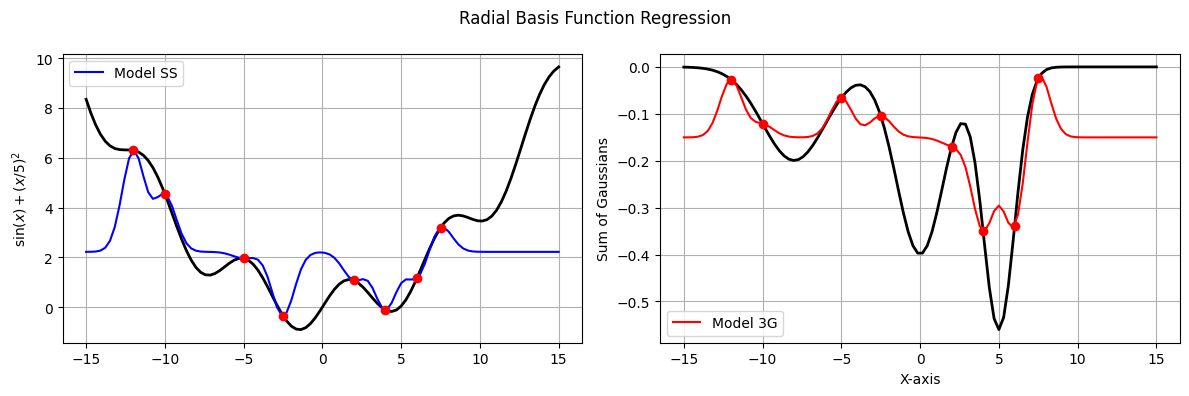

In [ ]:
Y_RBF_ss, Y_RBF_3g, x_points  = evalML(x_points, RBF_model_SS, RBF_model_3G)
plot_results(x_points, Y_RBF_ss, Y_RBF_3g, title='Radial Basis Function Regression')

## Decision Trees (DTs)

In [ ]:
##########################
# Decision Trees sklearn #
##########################

from sklearn.tree import DecisionTreeRegressor

In [ ]:
##########################
# Training Decision Tree #
##########################
# Creating a model that learns the 3 Gaussians function
DT_model_3G   = DecisionTreeRegressor()
DT_model_3G.fit(Xtrain, Ytrain_3g)

# Creating a model that learns the Sin + Square function
DT_model_SS   = DecisionTreeRegressor()
DT_model_SS.fit(Xtrain, Ytrain_ss)

DecisionTreeRegressor()

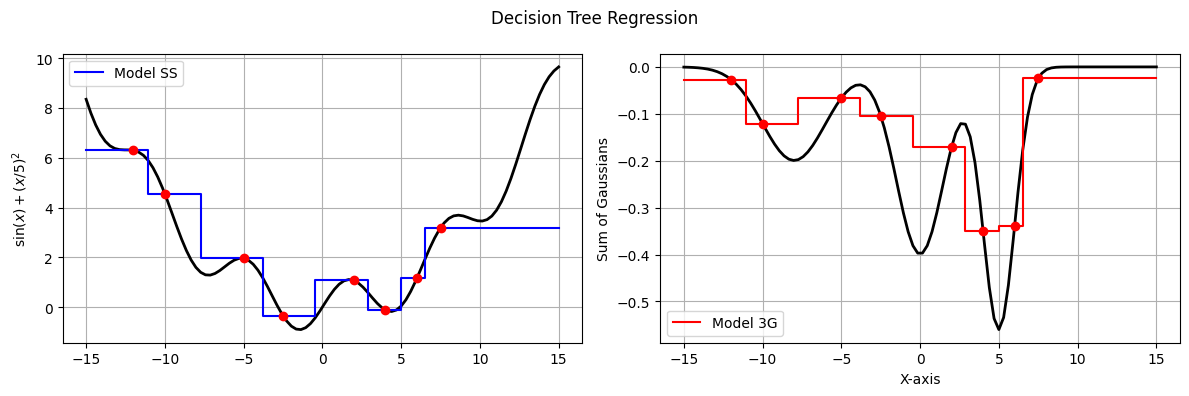

In [ ]:
Y_DT_ss, Y_DT_3g, x_points  = evalML(x_points, DT_model_SS, DT_model_3G)
plot_results(x_points, Y_DT_ss, Y_DT_3g, title='Decision Tree Regression', step_plot=True)

In [ ]:
##########################
# AdaBoost Trees sklearn #
##########################

from sklearn.ensemble import AdaBoostRegressor

In [ ]:
# Creating a model that learns the 3 Gaussians function
AdaB_model_3G = AdaBoostRegressor()
AdaB_model_3G.fit(Xtrain, Ytrain_3g.flatten())

# Creating a model that learns the Sin + Square function
AdaB_model_SS = AdaBoostRegressor()
AdaB_model_SS.fit(Xtrain, Ytrain_ss.flatten())

AdaBoostRegressor()

## Neural Network

In [ ]:
###########################
# Neural Networks sklearn #
###########################

# Warning: this is a naive NN implementation.

from sklearn.neural_network import MLPRegressor

In [ ]:
##################
# Neural Network #
##################

# Creating a model that learns the Sin + (x/5)^2 function
NN_model_SS = MLPRegressor(random_state=0,
                           learning_rate='adaptive',
                           alpha=0.001,
                           max_iter=10000,
                           solver='lbfgs',
                           activation='relu'
                           )
NN_model_SS.fit(Xtrain, Ytrain_ss.flatten())

# Creating a model that learns the 3 Gaussians function
NN_model_3G = MLPRegressor(random_state=1,
                           learning_rate='adaptive',
                           alpha=0.001,
                           max_iter=10000,
                           solver='lbfgs',
                           activation='relu'
                           )

NN_model_3G.fit(Xtrain, Ytrain_3g.flatten())

MLPRegressor(alpha=0.001, learning_rate='adaptive', max_iter=10000,
             random_state=1, solver='lbfgs')

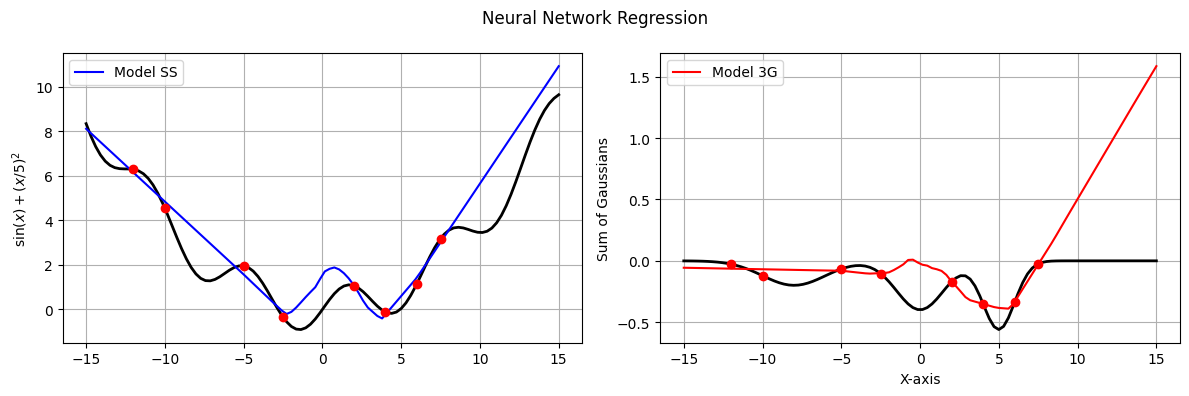

In [ ]:
Y_NN_ss, Y_NN_3g, x_points  = evalML(x_points, NN_model_SS, NN_model_3G)
plot_results(x_points, Y_NN_ss, Y_NN_3g, title='Neural Network Regression')

## Gaussian Process

In [ ]:
###########################
# Gaussian Process sklearn #
###########################

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

kernelRBF  = RBF()
GPmodel_SS = GaussianProcessRegressor(kernel=kernelRBF,
                                        n_restarts_optimizer=10,
                                        normalize_y=True)
GPmodel_SS.fit(Xtrain, Ytrain_ss)

GPmodel_3G = GaussianProcessRegressor(n_restarts_optimizer=10,
                                        normalize_y=True)
GPmodel_3G.fit(Xtrain, Ytrain_3g)

GaussianProcessRegressor(n_restarts_optimizer=10, normalize_y=True)

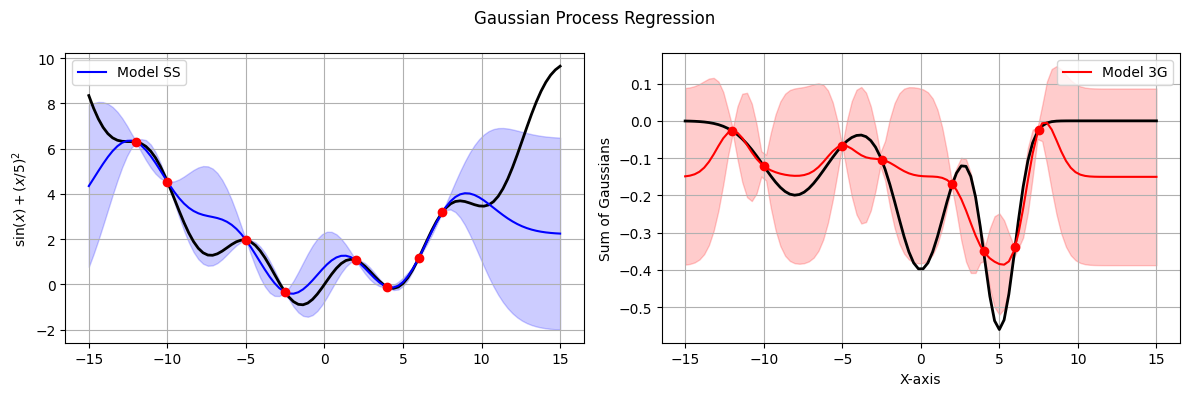

In [ ]:
Y_GP_ss, Y_GP_3g, YGP_ss_var, YGP_3g_var  = evalML(x_points,
                                                   GPmodel_SS,
                                                   GPmodel_3G,
                                                   GP_model=True)

plot_results(x_points, Y_GP_ss, Y_GP_3g,
             Yplot_ss_var=YGP_ss_var,
             Yplot_3g_var=YGP_3g_var,
             title='Gaussian Process Regression')
